# 05 Unified Evaluation Engine

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `05-unified-evaluation-engine.ipynb`

In [1]:
# Start coding here
# ==========================================
# Notebook 05
# Unified Evaluation Engine
# ==========================================

import pandas as pd
import numpy as np

from rouge_score import rouge_scorer

from bert_score import score

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [2]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [3]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [4]:
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

In [5]:
def exact_match(prediction, reference):

    return int(prediction.strip().lower() == reference.strip().lower())

In [6]:
def compute_bleu(prediction, reference):

    smoothie = SmoothingFunction().method1

    score_value = sentence_bleu(
        [reference.split()], prediction.split(), smoothing_function=smoothie
    )

    return float(score_value)

In [7]:
def compute_rouge(prediction, reference):

    scores = rouge.score(reference, prediction)

    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
    }

In [8]:
def compute_bertscore(prediction, reference):

    P, R, F1 = score([prediction], [reference], lang="en", verbose=False)

    return {
        "bertscore_precision": float(P.item()),
        "bertscore_recall": float(R.item()),
        "bertscore_f1": float(F1.item()),
    }

In [9]:
def embedding_similarity(prediction, reference, model):

    pred_emb = model.encode(prediction)

    ref_emb = model.encode(reference)

    similarity = cosine_similarity(pred_emb.reshape(1, -1), ref_emb.reshape(1, -1))[0][
        0
    ]

    return float(similarity)

In [10]:
def evaluate_response(prediction, reference):

    em = exact_match(prediction, reference)

    bleu = compute_bleu(prediction, reference)

    rouge_scores = compute_rouge(prediction, reference)

    bert_scores = compute_bertscore(prediction, reference)

    emb_score = embedding_similarity(prediction, reference, embedding_model)

    return {
        "exact_match": em,
        "bleu": bleu,
        **rouge_scores,
        **bert_scores,
        "embedding_similarity": emb_score,
    }

In [11]:
prediction = "AWS is Amazon's cloud platform."

reference = "AWS is Amazon Web Services, a cloud computing platform."

evaluate_response(prediction, reference)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'exact_match': 0,
 'bleu': 0.060713336587447424,
 'rouge1': 0.6666666666666667,
 'rouge2': 0.3076923076923077,
 'rougeL': 0.6666666666666667,
 'bertscore_precision': 0.9463489055633545,
 'bertscore_recall': 0.9117016792297363,
 'bertscore_f1': 0.9287022948265076,
 'embedding_similarity': 0.9199941754341125}

In [12]:
results = []

In [13]:
for _, row in df.iterrows():

    result = evaluate_response(row["generated_response"], row["ground_truth"])

    results.append(result)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In [14]:
results_df = pd.DataFrame(results)

results_df.head()

,exact_match,bleu,rouge1,rouge2,rougeL,bertscore_precision,bertscore_recall,bertscore_f1,embedding_similarity
0,0,0.060713,0.666667,0.307692,0.666667,0.946349,0.911702,0.928702,0.919994
1,0,0.046258,0.500000,0.142857,0.375000,0.930594,0.903113,0.916648,0.911832
2,0,0.090574,0.666667,0.200000,0.666667,0.974678,0.939706,0.956872,0.885961
3,0,0.057951,0.400000,0.000000,0.400000,0.940704,0.921139,0.930819,0.874929
4,0,0.057951,0.400000,0.000000,0.400000,0.939632,0.920771,0.930106,0.878420


In [15]:
evaluation_df = pd.concat([df, results_df], axis=1)

In [16]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,exact_match,bleu,rouge1,rouge2,rougeL,bertscore_precision,bertscore_recall,bertscore_f1,embedding_similarity
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0,0.060713,0.666667,0.307692,0.666667,0.946349,0.911702,0.928702,0.919994
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0,0.046258,0.500000,0.142857,0.375000,0.930594,0.903113,0.916648,0.911832
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0,0.090574,0.666667,0.200000,0.666667,0.974678,0.939706,0.956872,0.885961
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000,0.940704,0.921139,0.930819,0.874929
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0,0.057951,0.400000,0.000000,0.400000,0.939632,0.920771,0.930106,0.878420


In [19]:
def calculate_quality_score(row):

    score = (
        0.10 * row["exact_match"]
        + 0.10 * row["bleu"]
        + 0.20 * row["rougeL"]
        + 0.30 * row["bertscore_f1"]
        + 0.30 * row["embedding_similarity"]
    )

    return round(score, 4)

In [20]:
evaluation_df["quality_score"] = evaluation_df.apply(calculate_quality_score, axis=1)

In [21]:
evaluation_df[["quality_score"]].head()

,quality_score
0,0.6940
1,0.6282
2,0.6952
3,0.6275
4,0.6284


In [22]:
def quality_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [23]:
evaluation_df["quality_label"] = evaluation_df["quality_score"].apply(quality_label)

In [24]:
evaluation_df[["question", "quality_score", "quality_label"]]

,question,quality_score,quality_label
0,What is AWS?,0.6940,Poor
1,What is Azure?,0.6282,Poor
2,What is Google Cloud?,0.6952,Poor
3,What is AWS?,0.6275,Poor
4,What is Azure?,0.6284,Poor
5,What is Google Cloud?,0.6561,Poor
6,What is Oracle Cloud?,0.6618,Poor
7,What is IBM Cloud?,0.6675,Poor
8,Question 8,0.4486,Poor
9,Question 9,0.4486,Poor


In [25]:
evaluation_df["quality_label"].value_counts()

quality_label
Poor    20
Name: count, dtype: int64

In [26]:
evaluation_df[
    ["bleu", "rougeL", "bertscore_f1", "embedding_similarity", "quality_score"]
].mean()

bleu                    0.096489
rougeL                  0.400417
bertscore_f1            0.886463
embedding_similarity    0.588006
quality_score           0.532095
dtype: float64

In [27]:
correlation = evaluation_df[
    ["bleu", "rougeL", "bertscore_f1", "embedding_similarity", "quality_score"]
].corr()

In [28]:
correlation

,bleu,rougeL,bertscore_f1,embedding_similarity,quality_score
bleu,1.000000,-0.551493,-0.813046,-0.904840,-0.850127
rougeL,-0.551493,1.000000,0.823815,0.779685,0.862251
bertscore_f1,-0.813046,0.823815,1.000000,0.980227,0.988053
embedding_similarity,-0.904840,0.779685,0.980227,1.000000,0.988940
quality_score,-0.850127,0.862251,0.988053,0.988940,1.000000


In [29]:
import matplotlib.pyplot as plt

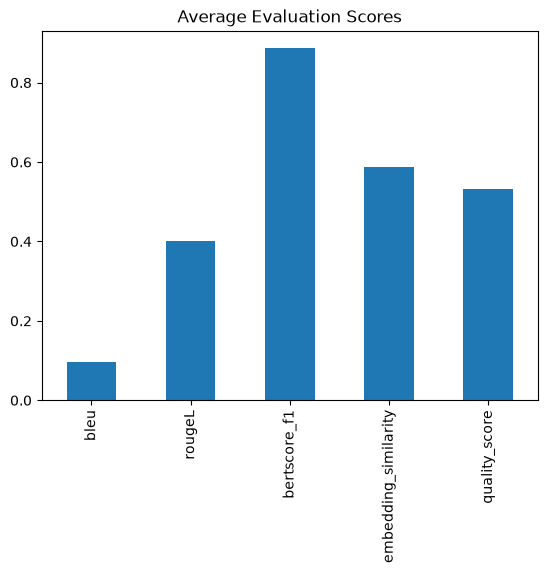

In [30]:
evaluation_df[
    ["bleu", "rougeL", "bertscore_f1", "embedding_similarity", "quality_score"]
].mean().plot(kind="bar")

plt.title("Average Evaluation Scores")

plt.show()

In [31]:
def generate_report(evaluation_df):

    report = {
        "records": len(evaluation_df),
        "avg_quality_score": round(evaluation_df["quality_score"].mean(), 4),
        "avg_bertscore": round(evaluation_df["bertscore_f1"].mean(), 4),
        "avg_rougeL": round(evaluation_df["rougeL"].mean(), 4),
    }

    return report

In [32]:
generate_report(evaluation_df)

{'records': 20,
 'avg_quality_score': 0.5321,
 'avg_bertscore': 0.8865,
 'avg_rougeL': 0.4004}

In [33]:
evaluation_df.to_csv(
    "../evaluation_results/unified_evaluation_results.csv", index=False
)

In [34]:
report_df = pd.DataFrame([generate_report(evaluation_df)])

report_df.to_csv("../reports/evaluation_summary.csv", index=False)

OSError: Cannot save file into a non-existent directory: '..\reports'